# Imports #

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from dataclasses import dataclass
from typing import Optional, List, Dict
import os

# Display settings
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'text.usetex': False  # Can be set to True if LaTeX is installed
})

# Configuration #

In [31]:
@dataclass
class PlotParams:
    """
    Class for storing plot style parameters.
    """
    linestyle: str = "-"
    color: str = "k"
    linewidth: float = 1.5
    marker: Optional[str] = None
    markersize: float = 6.0
    label: str = ""
    alpha: float = 1.0

# Data #

Experimental data for specific binding energy (E_b/A) for some stable nuclei.
Data is presented as a dictionary where the key is the element name and the value is a tuple (A, Z, E_binding_per_nucleon_MeV).

In [32]:
experimental_data_dict = {
    'H-2':   (2,   1,  1.112),
    'He-4':  (4,   2,  7.074),
    'Li-7':  (7,   3,  5.606),
    'Be-9':  (9,   4,  6.463),
    'C-12':  (12,  6,  7.680),
    'N-14':  (14,  7,  7.476),
    'O-16':  (16,  8,  7.976),
    'Na-23': (23,  11, 8.111),
    'Mg-24': (24,  12, 8.261),
    'Al-27': (27,  13, 8.332),
    'Ca-40': (40,  20, 8.551),
    'Fe-56': (56,  26, 8.790),
    'Cu-63': (63,  29, 8.752),
    'Kr-84': (84,  36, 8.713),
    'Sn-118':(118, 50, 8.523),
    'Xe-132':(132, 54, 8.448),
    'Pb-208':(208, 82, 7.868),
    'U-238': (238, 92, 7.570)
}

# Converting dictionary to numpy arrays for easier processing
data_list = list(experimental_data_dict.values())
A_exp = np.array([item[0] for item in data_list])
Z_exp = np.array([item[1] for item in data_list])
Eb_exp = np.array([item[2] for item in data_list]) # E_b / A

# Model #

Weizsaecker formula (semi-empirical mass formula).
The nuclear binding energy $E_b(A, Z)$ is described as a sum of several terms:

$$ E_b(A, Z) = a_V A - a_S A^{2/3} - a_C \frac{Z(Z-1)}{A^{1/3}} - a_A \frac{(A-2Z)^2}{A} + \delta(A, Z) $$

Where:
- $a_V$: Volume term
- $a_S$: Surface term
- $a_C$: Coulomb term
- $a_A$: Asymmetry term
- $\delta$: Pairing term

Specific binding energy: $\epsilon = E_b / A$.

In [33]:
def pairing_term(A, Z, a_P):
    """
    Calculates the pairing term delta(A, Z).
    """
    delta = np.zeros_like(A, dtype=float)
    
    # Determine parity of N and Z
    N = A - Z
    
    # even-even (Z even, N even -> A even)
    mask_ee = (Z % 2 == 0) & (N % 2 == 0)
    # odd-odd (Z odd, N odd -> A even)
    mask_oo = (Z % 2 != 0) & (N % 2 != 0)
    # even-odd or odd-even (A odd)
    # mask_eo = (A % 2 != 0) -> delta = 0 (already initialized to zeros)
    
    delta[mask_ee] = a_P * A[mask_ee]**(-0.5) # or A**(-3/4), varies in different sources. We'll use a_P / sqrt(A)
    delta[mask_oo] = -a_P * A[mask_oo]**(-0.5)
    
    return delta

In [34]:
def weizsaecker_formula(data_tuple, a_V, a_S, a_C, a_A, a_P):
    """
    Full Weizsaecker formula for specific binding energy E/A.
    data_tuple: (A, Z)
    """
    A, Z = data_tuple
    
    # Volume
    E_V = a_V * A
    
    # Surface
    E_S = -a_S * A**(2/3)
    
    # Coulomb
    E_C = -a_C * Z * (Z - 1) * A**(-1/3)
    
    # Asymmetry
    E_A = -a_A * (A - 2*Z)**2 * A**(-1)
    
    # Pairing
    E_P = pairing_term(A, Z, a_P)
    
    E_total = E_V + E_S + E_C + E_A + E_P
    
    return E_total / A  # Return specific energy

# Fitting #

In [35]:
# Initial guesses for coefficients (in MeV)
# a_V ~ 15.7, a_S ~ 17.2, a_C ~ 0.71, a_A ~ 23.2, a_P ~ 11.2
p0 = [15.7, 17.2, 0.71, 23.2, 11.2]

# Fit the model to experimental data
popt, pcov = curve_fit(weizsaecker_formula, (A_exp, Z_exp), Eb_exp, p0=p0)

a_V_fit, a_S_fit, a_C_fit, a_A_fit, a_P_fit = popt
perr = np.sqrt(np.diag(pcov))

print("Approximation results (MeV):")
print(f"a_V = {a_V_fit:.3f} ± {perr[0]:.3f}")
print(f"a_S = {a_S_fit:.3f} ± {perr[1]:.3f}")
print(f"a_C = {a_C_fit:.3f} ± {perr[2]:.3f}")
print(f"a_A = {a_A_fit:.3f} ± {perr[3]:.3f}")
print(f"a_P = {a_P_fit:.3f} ± {perr[4]:.3f}")

Approximation results (MeV):
a_V = 11.037 ± 0.418
a_S = 8.361 ± 0.731
a_C = -0.054 ± 0.084
a_A = 44.408 ± 4.206
a_P = 9.408 ± 0.552


# Visualization #

In [36]:
# Create an array A for a smooth curve
A_smooth = np.linspace(1, 250, 500)

# To plot theoretical curves, we need Z for each A.
# Use the line of beta-stability: Z approx A / (2 + 0.015 * A^(2/3))
Z_smooth = A_smooth / (2 + 0.015 * A_smooth**(2/3))

# Calculate individual contributions (specific energy)
# 1. Volume energy only
y1 = (a_V_fit * A_smooth) / A_smooth

# 2. Volume + Surface
y2 = (a_V_fit * A_smooth - a_S_fit * A_smooth**(2/3)) / A_smooth

# 3. + Coulomb
y3 = (a_V_fit * A_smooth - a_S_fit * A_smooth**(2/3) - a_C_fit * Z_smooth * (Z_smooth - 1) * A_smooth**(-1/3)) / A_smooth

# 4. + Asymmetry
y4 = (a_V_fit * A_smooth - a_S_fit * A_smooth**(2/3) - a_C_fit * Z_smooth * (Z_smooth - 1) * A_smooth**(-1/3) - a_A_fit * (A_smooth - 2*Z_smooth)**2 * A_smooth**(-1)) / A_smooth

# 5. Total model (with pairing - for a smooth curve, we'll take the "average" value, i.e., 0, or show oscillations, but usually a smooth line without pairing is drawn for the trend)
# We will plot y4 as the main "liquid drop" line, as pairing causes oscillations around it.
# But for completeness, we can add y5 for even-even nuclei, for example.
# In this case, y4 is the "Liquid Drop Model" without pairing.

# Calculate y5 for even-even nuclei (pairing term is positive)
# For plotting, we assume Z_smooth and A_smooth represent even-even nuclei for this specific curve.
# This is a simplification for visualization, as Z_smooth is not strictly integer or even.
# The pairing term is a_P / sqrt(A) for even-even nuclei.
y5 = (a_V_fit * A_smooth - a_S_fit * A_smooth**(2/3) - a_C_fit * Z_smooth * (Z_smooth - 1) * A_smooth**(-1/3) - a_A_fit * (A_smooth - 2*Z_smooth)**2 * A_smooth**(-1) + a_P_fit * A_smooth**(-0.5)) / A_smooth

Plot saved to: d:\git\MIPT\5_sem\calculus_math\Kozhemyachenko\weizsaecker_fit_v2.pdf


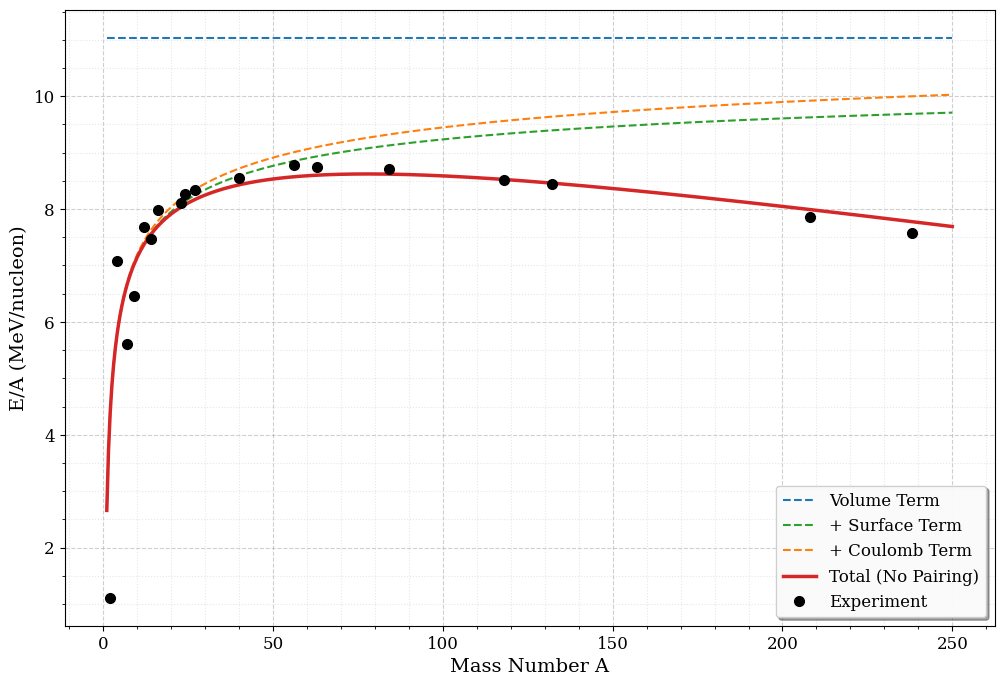

In [38]:
# Plot settings
plot_configs = {
    "Volume": PlotParams(linestyle="--", color="tab:blue", label="Volume Term", linewidth=1.5),
    "Vol+Surf": PlotParams(linestyle="--", color="tab:green", label="+ Surface Term", linewidth=1.5),
    "Vol+Surf+Coul": PlotParams(linestyle="--", color="tab:orange", label="+ Coulomb Term", linewidth=1.5),
    "Total (Liquid Drop)": PlotParams(linestyle="-", color="tab:red", linewidth=2.5, label="Total (No Pairing)"),
    "Total (Even-Even)": PlotParams(linestyle="-", color="tab:purple", linewidth=1.5, label="Total + Pairing (Even-Even)"),
    "Experiment": PlotParams(marker="o", color="black", linestyle="None", label="Experiment", markersize=7.0)
}

plt.figure(figsize=(12, 8))

# Plotting curves
# Drawing order (zorder): higher value means on top
plt.plot(A_smooth, y1, linestyle=plot_configs["Volume"].linestyle, color=plot_configs["Volume"].color, 
         label=plot_configs["Volume"].label, linewidth=plot_configs["Volume"].linewidth, zorder=1)

plt.plot(A_smooth, y2, linestyle=plot_configs["Vol+Surf"].linestyle, color=plot_configs["Vol+Surf"].color, 
         label=plot_configs["Vol+Surf"].label, linewidth=plot_configs["Vol+Surf"].linewidth, zorder=2)

plt.plot(A_smooth, y3, linestyle=plot_configs["Vol+Surf+Coul"].linestyle, color=plot_configs["Vol+Surf+Coul"].color, 
         label=plot_configs["Vol+Surf+Coul"].label, linewidth=plot_configs["Vol+Surf+Coul"].linewidth, zorder=3)

plt.plot(A_smooth, y4, linestyle=plot_configs["Total (Liquid Drop)"].linestyle, color=plot_configs["Total (Liquid Drop)"].color, 
         linewidth=plot_configs["Total (Liquid Drop)"].linewidth, label=plot_configs["Total (Liquid Drop)"].label, zorder=4)


# Plotting experimental points
plt.plot(A_exp, Eb_exp, 
         marker=plot_configs["Experiment"].marker, 
         color=plot_configs["Experiment"].color, 
         linestyle=plot_configs["Experiment"].linestyle, 
         label=plot_configs["Experiment"].label,
         markersize=plot_configs["Experiment"].markersize,
         zorder=5)

# Styling
plt.xlabel("Mass Number A", fontsize=14)
plt.ylabel("E/A (MeV/nucleon)", fontsize=14)

# Grid
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.grid(True, which='minor', linestyle=':', alpha=0.3)
plt.minorticks_on()

# Legend
# Placing legend in the "best" location, but can be fixed if it overlaps data
# framealpha=0.95 makes the legend background almost opaque so text is readable over lines
plt.legend(fontsize=12, loc='lower right', framealpha=0.95, shadow=True)


# Saving
save_path = os.path.join(os.getcwd(), "weizsaecker_fit_v2.pdf")
plt.savefig(save_path, bbox_inches='tight')
print(f"Plot saved to: {save_path}")

plt.show()